## EXPLORING THE DATA


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
print("Chargement des données...")
aisles = pd.read_csv('./datasets/aisles.csv')
departments = pd.read_csv('./datasets/departments.csv')
products = pd.read_csv('./datasets/products.csv')
orders = pd.read_csv('./datasets/orders.csv')
order_products = pd.read_csv('./datasets/order_products.csv') 

print("Fusion en cours...")
products_enriched = products.merge(aisles, on='aisle_id', how='left')
products_enriched = products_enriched.merge(departments, on='department_id', how='left')

orders_details = order_products.merge(orders, on='order_id', how='left')

df_master = orders_details.merge(products_enriched, on='product_id', how='left')

print("Fusion terminée !")
display(df_master.head())
print(f"Dimensions du dataset final : {df_master.shape}")

Chargement des données...
Fusion en cours...
Fusion terminée !


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120.0,1.0,1.0,202279.0,3.0,5.0,9.0,8.0,Organic Egg Whites,86.0,16.0,eggs,dairy eggs
1,2,28985.0,2.0,1.0,202279.0,3.0,5.0,9.0,8.0,Michigan Organic Kale,83.0,4.0,fresh vegetables,produce
2,2,9327.0,3.0,0.0,202279.0,3.0,5.0,9.0,8.0,Garlic Powder,104.0,13.0,spices seasonings,pantry
3,2,45918.0,4.0,1.0,202279.0,3.0,5.0,9.0,8.0,Coconut Butter,19.0,13.0,oils vinegars,pantry
4,2,30035.0,5.0,0.0,202279.0,3.0,5.0,9.0,8.0,Natural Sweetener,17.0,13.0,baking ingredients,pantry


Dimensions du dataset final : (13692886, 14)


In [3]:
print("Nombre de Valeurs nul dans le Dataset",df_master.isnull())
print("<=======================>")
print("Nombre de NaN dans chaque column:", df_master.isnull().sum())


Nombre de Valeurs nul dans le Dataset           order_id  product_id  add_to_cart_order  reordered  user_id  \
0            False       False              False      False    False   
1            False       False              False      False    False   
2            False       False              False      False    False   
3            False       False              False      False    False   
4            False       False              False      False    False   
...            ...         ...                ...        ...      ...   
13692881     False       False              False      False    False   
13692882     False       False              False      False    False   
13692883     False       False              False      False    False   
13692884     False       False              False      False    False   
13692885     False       False              False      False    False   

          order_number  order_dow  order_hour_of_day  days_since_prior_order  \
0    

## 

## EASY	Find the best seller per  departement 

#### je dois d'abord trouver les product_id qui sont le plus commandés

In [4]:
ID_Product_Greater = df_master['product_id'].value_counts(dropna=False)
print(ID_Product_Greater)



product_id
24852.0    199654
13176.0    160615
21137.0    111975
21903.0    101915
47209.0     90372
            ...  
27594.0         1
20222.0         1
17113.0         1
10074.0         1
36614.0         1
Name: count, Length: 49068, dtype: int64


### et les traduire avec leurs noms de produit et trouver la correlation  

In [5]:
dfProductaffilate= (df_master[["product_id", "product_name"]].head())
display(dfProductaffilate)

,product_id,product_name
0,33120.0,Organic Egg Whites
1,28985.0,Michigan Organic Kale
2,9327.0,Garlic Powder
3,45918.0,Coconut Butter
4,30035.0,Natural Sweetener


In [6]:

ventes =(df_master.groupby(["department_id", "department", "product_id", "product_name"], as_index=False).size().rename(columns={"size": "nombres_Dachat"}))
ventes.head()



,department_id,department,product_id,product_name,nombres_Dachat
0,1.0,frozen,4.0,Smart Ones Classic Favorites Mini Rigatoni Wit...,149
1,1.0,frozen,8.0,Cut Russet Potatoes Steam N' Mash,69
2,1.0,frozen,12.0,Chocolate Fudge Layer Cake,108
3,1.0,frozen,18.0,Pizza for One Suprema Frozen Pizza,51
4,1.0,frozen,30.0,"Three Cheese Ziti, Marinara with Meatballs",34


In [7]:
df = pd.DataFrame(df_master)
df = df.set_index("department")
df.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle
department,,,,,,,,,,,,,
dairy eggs,2,33120.0,1.0,1.0,202279.0,3.0,5.0,9.0,8.0,Organic Egg Whites,86.0,16.0,eggs
produce,2,28985.0,2.0,1.0,202279.0,3.0,5.0,9.0,8.0,Michigan Organic Kale,83.0,4.0,fresh vegetables
pantry,2,9327.0,3.0,0.0,202279.0,3.0,5.0,9.0,8.0,Garlic Powder,104.0,13.0,spices seasonings
pantry,2,45918.0,4.0,1.0,202279.0,3.0,5.0,9.0,8.0,Coconut Butter,19.0,13.0,oils vinegars
pantry,2,30035.0,5.0,0.0,202279.0,3.0,5.0,9.0,8.0,Natural Sweetener,17.0,13.0,baking ingredients


### nous n'avons pas les best seller , je vais chercher a faire une variable "Best Seller"

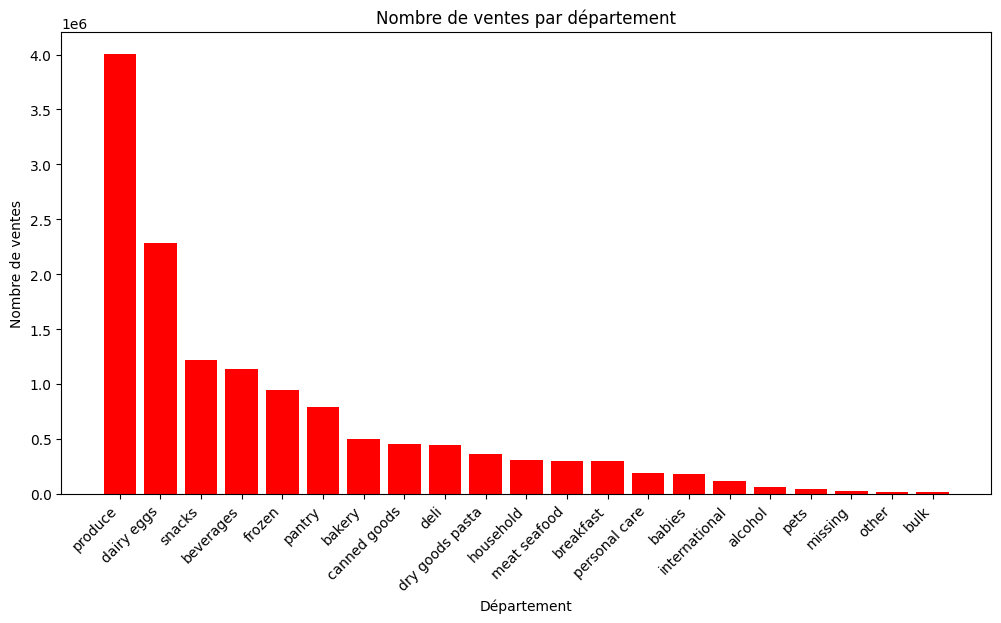

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt

# Compter le nombre de ventes par département
ventes_par_dept = df_master.groupby('department').size().sort_values(ascending=False)


plt.figure(figsize=(12, 6))
plt.bar(ventes_par_dept.index, ventes_par_dept.values, color='red')
plt.title('Nombre de ventes par département')
plt.xlabel('Département')
plt.ylabel('Nombre de ventes')
plt.xticks(rotation=45, ha='right')
plt.show()